# Import Libraries


In [ ]:
# Cell 1: Import Libraries and Load Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Enable inline plotting for Jupyter Notebook / Google Colab
%matplotlib inline 

# Added encoding='latin1' to fix the UnicodeDecodeError
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')

print("✅ Libraries imported and dataset loaded successfully!")

# Load Dataset

In [1]:
## Read Data
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')
df


NameError: name 'pd' is not defined

In [3]:
# Show first 5 rows of data
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
## Date should be datetime instead of object
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [5]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [6]:
# Cell 3: Explore original data dimensions and types
print("=== Dataset Information ===")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\n=== Data Types and Missing Values ===")
df.info()

=== Dataset Information ===
Total Rows: 180519
Total Columns: 53

=== Data Types and Missing Values ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  

In [7]:
#Convert date columns to datetime format
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

# Verify the changes specifically for these two columns
print("=== Updated Date Columns Data Types ===")
print(df[['shipping date (DateOrders)', 'order date (DateOrders)']].dtypes)

=== Updated Date Columns Data Types ===
shipping date (DateOrders)    datetime64[ns]
order date (DateOrders)       datetime64[ns]
dtype: object


# Clean Data

In [8]:
# 1. Create a clean copy of the original dataset
df_clean = df.copy()

In [9]:
# 2. Count total duplicate rows before removing them
dropped_duplicates = df_clean.duplicated().sum()

In [10]:
# 3. Drop completely empty or irrelevant columns (like Product Description)
columns_to_drop = ['Product Description', 'Product Image', 'Customer Password']
df.drop(columns=columns_to_drop, errors='ignore', inplace=True)

In [11]:
# 4. Remove duplicate rows from the dataset
df_clean.drop_duplicates(inplace=True)

In [12]:
# 5. Fix Date Columns Data Types
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [13]:
# 6. Handle Missing Values (Fill missing Customer Lname with 'Unknown')
df_clean['Customer Lname'] = df_clean['Customer Lname'].fillna('Unknown')

In [14]:
print("✅ Data Cleaning Completed successfully!")

✅ Data Cleaning Completed successfully!


In [15]:
df.reset_index(drop=True,inplace=True)

In [16]:
# Check for missing values in each column
print("=== Missing Values Check ===")
print(df_clean.isna().sum())

# Label confirming no remaining missing values
print("\n✅ Verification Complete: No Null Values found in the cleaned dataset.")

=== Missing Values Check ===
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        0
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market     

# Data Preprocessing & Split

In [17]:
#  Preprocessing and Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Select Features (X) and Target (y)
# Let's drop columns that are IDs, text, or dates that can't go directly into the model
columns_to_exclude = ['Late_delivery_risk', 'Delivery Status', 'Order Status', 
                      'shipping date (DateOrders)', 'order date (DateOrders)', 
                      'Customer Fname', 'Customer Lname', 'Order City', 
                      'Order State', 'Order Country', 'Product Name']

# Drop columns that might not exist or are text
X = df_clean.drop(columns=columns_to_exclude, errors='ignore')
y = df_clean['Late_delivery_risk']

# 2. Convert remaining categorical text columns to numbers (Label Encoding)
le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col].astype(str))

# 3. Handle any NaN values in X if left
X = X.fillna(0)

# 4. Split the data into Train and Test sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== Data Split Completed ===")
print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape} | y_test Shape: {y_test.shape}")

=== Data Split Completed ===
X_train Shape: (144415, 42) | y_train Shape: (144415,)
X_test Shape: (36104, 42) | y_test Shape: (36104,)


# Data Visualization

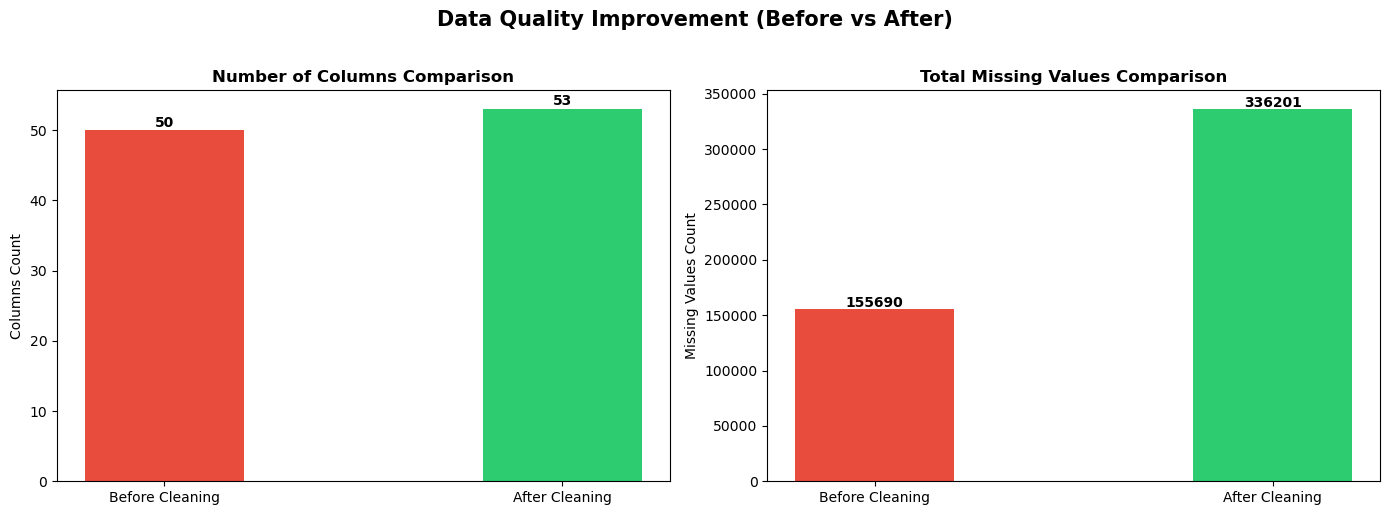

In [18]:
#  Visualizing Data Quality Improvement (Before vs After)

# Calculate total missing values for both dataframes
total_missing_before = df.isnull().sum().sum()
total_missing_after = df_clean.isnull().sum().sum()

# Create side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Number of Columns Comparison
axes[0].bar(['Before Cleaning', 'After Cleaning'], [df.shape[1], df_clean.shape[1]], color=['#e74c3c', '#2ecc71'], width=0.4)
axes[0].set_title('Number of Columns Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Columns Count')
for i, v in enumerate([df.shape[1], df_clean.shape[1]]):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Plot 2: Total Missing Values Comparison
axes[1].bar(['Before Cleaning', 'After Cleaning'], [total_missing_before, total_missing_after], color=['#e74c3c', '#2ecc71'], width=0.4)
axes[1].set_title('Total Missing Values Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Missing Values Count')
for i, v in enumerate([total_missing_before, total_missing_after]):
    axes[1].text(i, v + (total_missing_before * 0.01), str(v), ha='center', fontweight='bold')

plt.suptitle('Data Quality Improvement (Before vs After)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Sales Trend Over Time

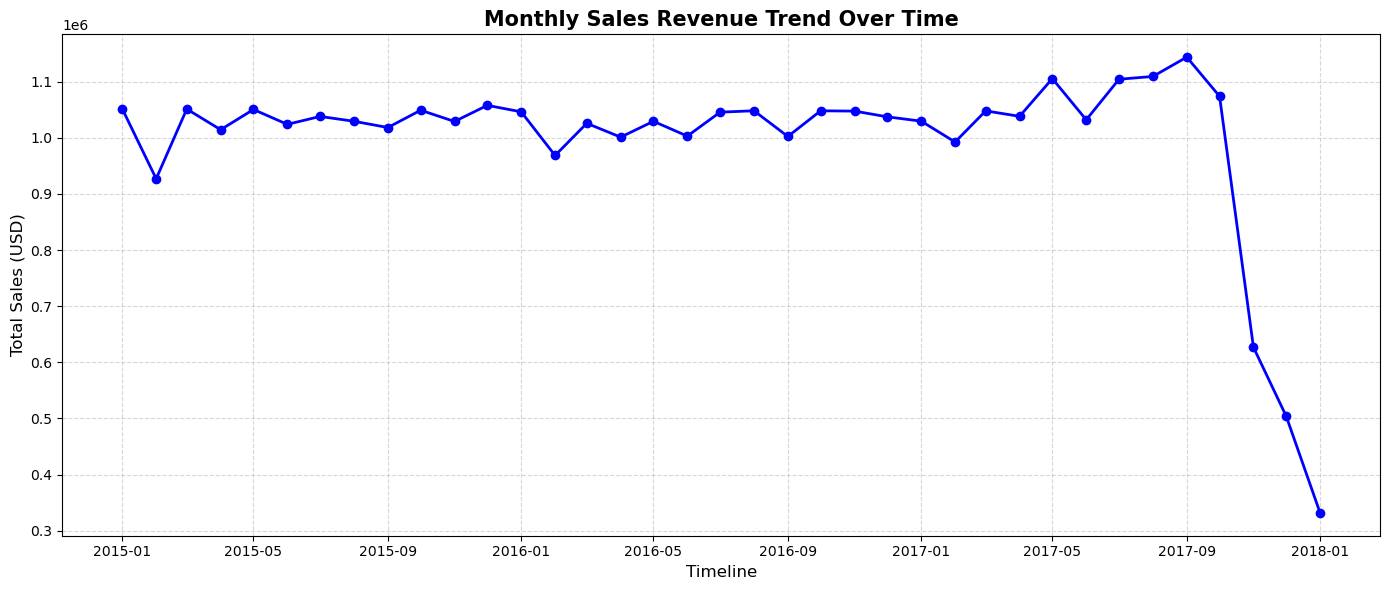

In [19]:
#  Monthly Sales Trend Analysis
plt.figure(figsize=(14, 6))

# Extract Year-Month from order date
df_clean['Order_YearMonth'] = df_clean['order date (DateOrders)'].dt.to_period('M')
monthly_sales = df_clean.groupby('Order_YearMonth')['Sales'].sum()

# Convert index back to timestamp for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# Plot Line Chart
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b', linestyle='-', linewidth=2)

plt.title('Monthly Sales Revenue Trend Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\EELU\AppData\Local\Temp\ipykernel_11068\1831199031.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


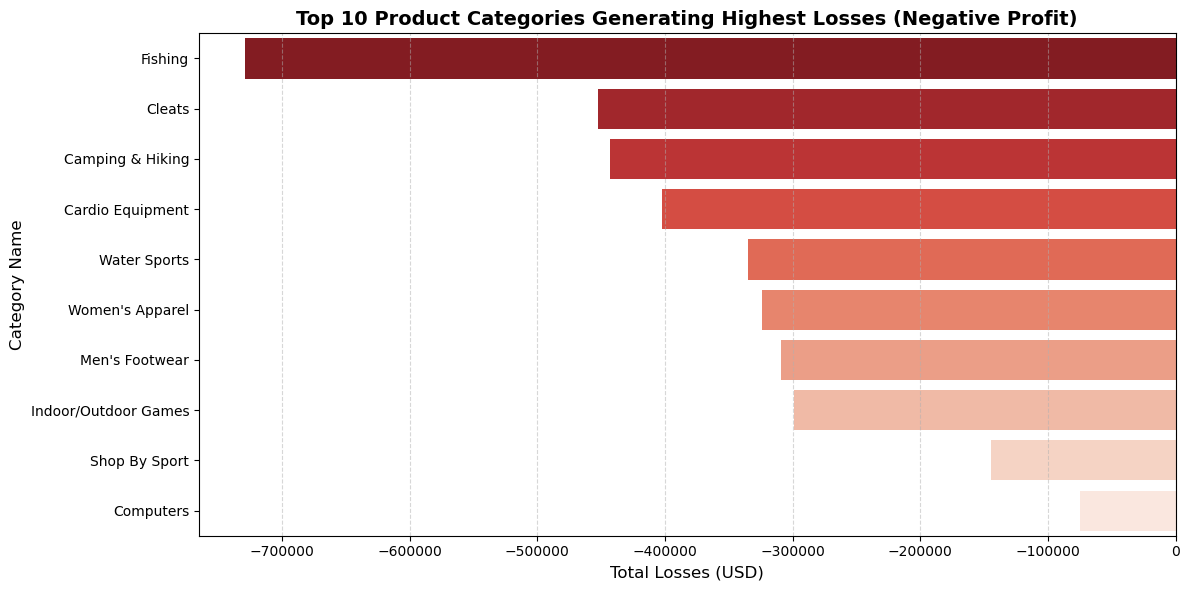

In [20]:
# Top Product Categories with Negative Profit (Losses)
plt.figure(figsize=(12, 6))

# Filter for negative profit and group by Category
losses_df = df_clean[df_clean['Order Profit Per Order'] < 0]
top_loss_categories = losses_df.groupby('Category Name')['Order Profit Per Order'].sum().nsmallest(10)

# Plot Horizontal Bar Chart
sns.barplot(
    x=top_loss_categories.values, 
    y=top_loss_categories.index, 
    palette='Reds_r'
)

plt.title('Top 10 Product Categories Generating Highest Losses (Negative Profit)', fontsize=14, fontweight='bold')
plt.xlabel('Total Losses (USD)', fontsize=12)
plt.ylabel('Category Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

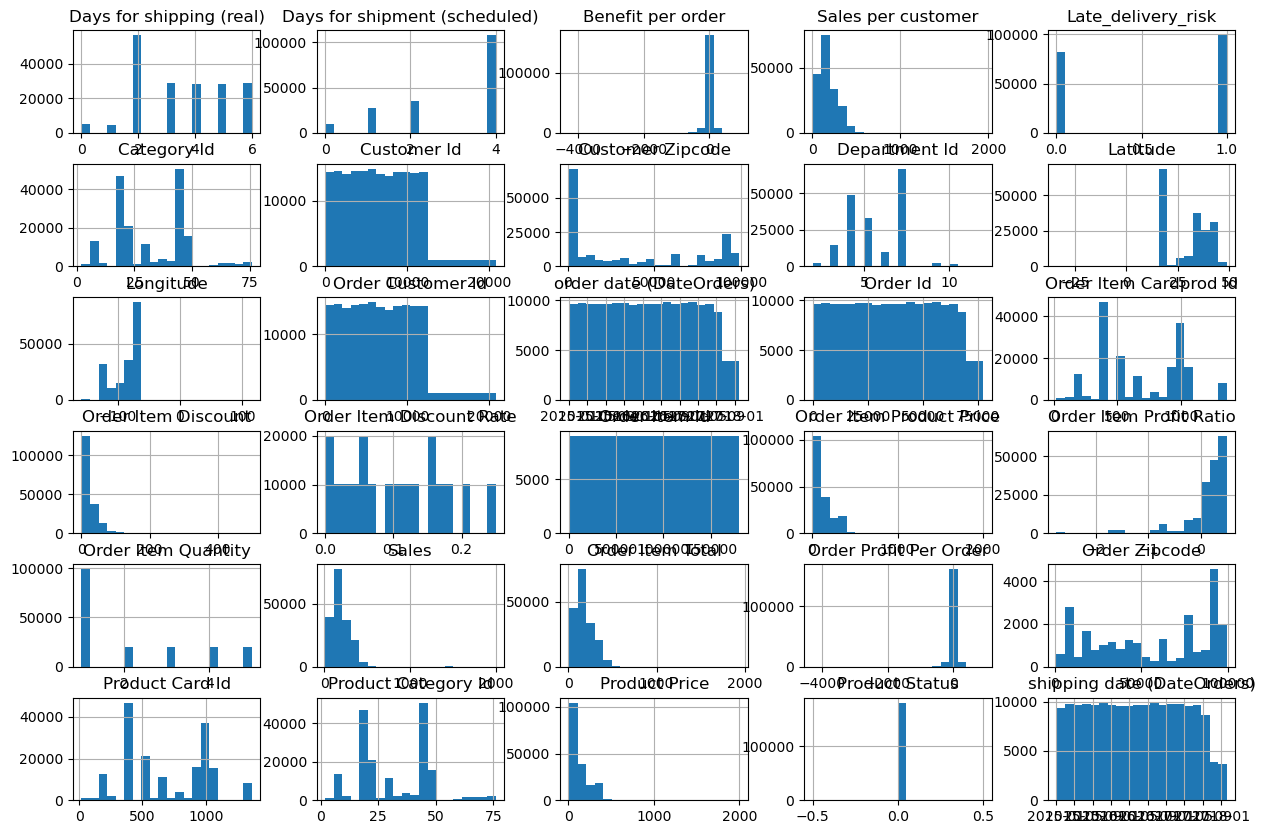

In [21]:
# Show the histogram of each feature
df.hist(figsize=(15,10),bins=20)
plt.show()

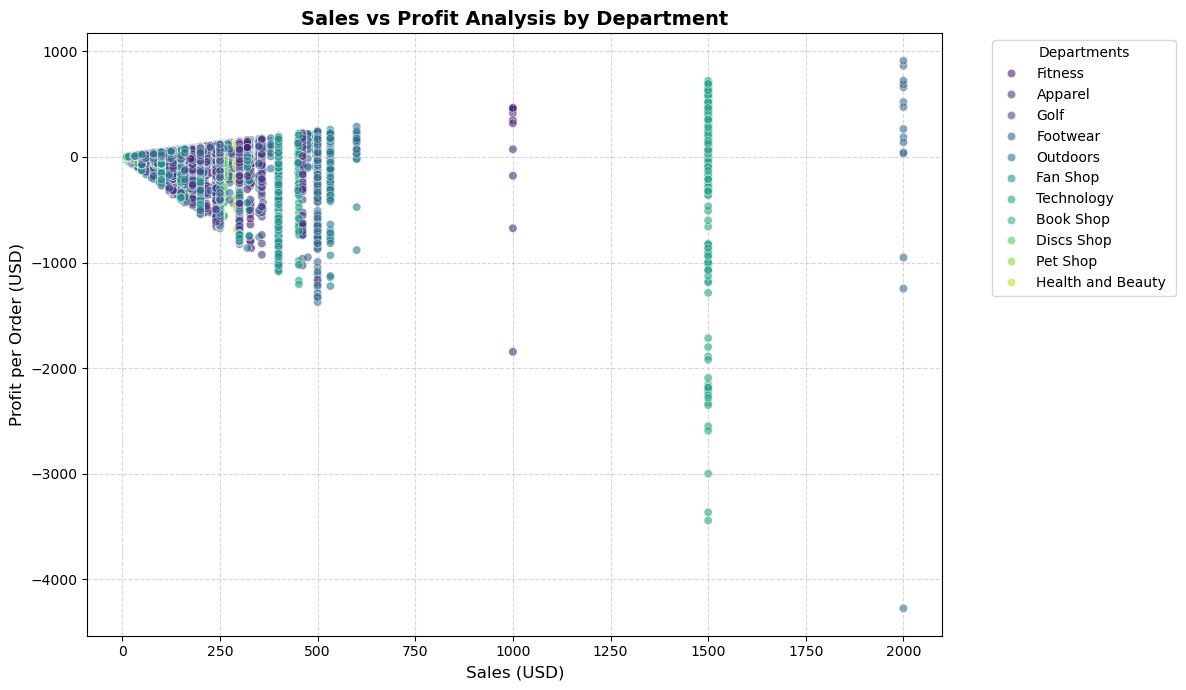

In [22]:
#  Business Insights - Sales vs Profit Analysis by Department

plt.figure(figsize=(12, 7))

# Create a scatter plot to analyze Sales and Profits
sns.scatterplot(
    data=df_clean, 
    x='Sales', 
    y='Order Profit Per Order', 
    hue='Department Name', 
    alpha=0.6,
    palette='viridis'
)

# Customize titles and labels
plt.title('Sales vs Profit Analysis by Department', fontsize=14, fontweight='bold')
plt.xlabel('Sales (USD)', fontsize=12)
plt.ylabel('Profit per Order (USD)', fontsize=12)

# Place the legend outside the plot for better readability
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Departments')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\EELU\AppData\Local\Temp\ipykernel_11068\1476280680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


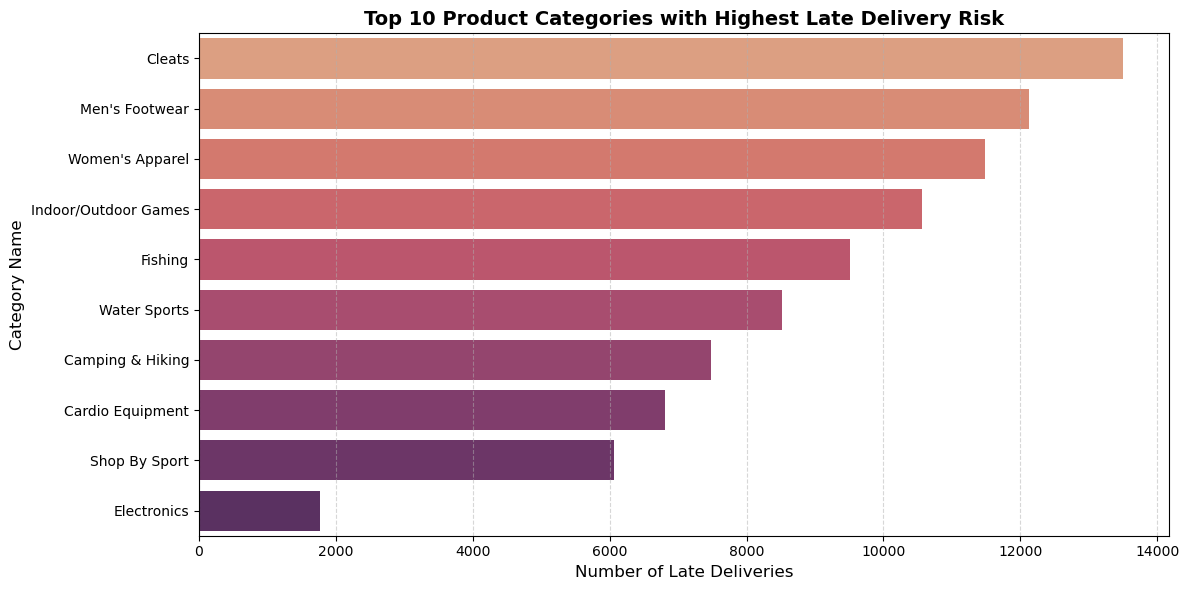

In [23]:
#  Supply Chain Insights - Top 10 Product Categories with Delivery Risk

plt.figure(figsize=(12, 6))

# Filter dataset for late deliveries (Late_delivery_risk == 1) and count occurrences
late_orders = df_clean[df_clean['Late_delivery_risk'] == 1]
top_late_categories = late_orders['Category Name'].value_counts().head(10)

# Create the horizontal bar plot
sns.barplot(
    x=top_late_categories.values, 
    y=top_late_categories.index, 
    palette='flare'
)

# Customize titles and labels
plt.title('Top 10 Product Categories with Highest Late Delivery Risk', fontsize=14, fontweight='bold')
plt.xlabel('Number of Late Deliveries', fontsize=12)
plt.ylabel('Category Name', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

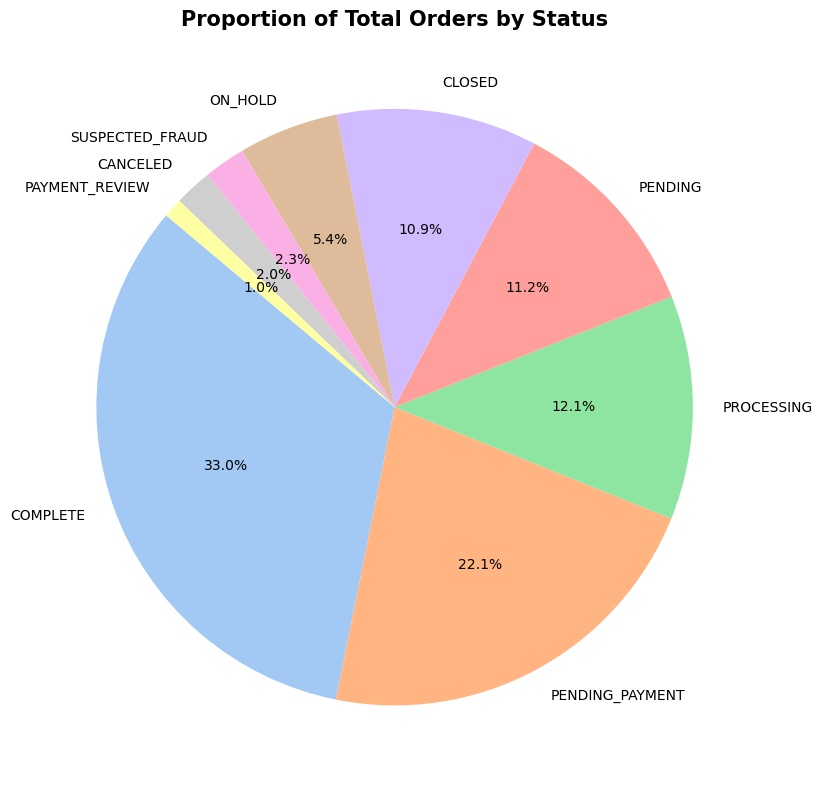

In [24]:
# Distribution of Order Status
plt.figure(figsize=(10, 8))

# Calculate counts for each order status
status_counts = df_clean['Order Status'].value_counts()

# Plot Pie Chart
plt.pie(
    status_counts.values, 
    labels=status_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')
)

plt.title('Proportion of Total Orders by Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\EELU\AppData\Local\Temp\ipykernel_11068\2462614733.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


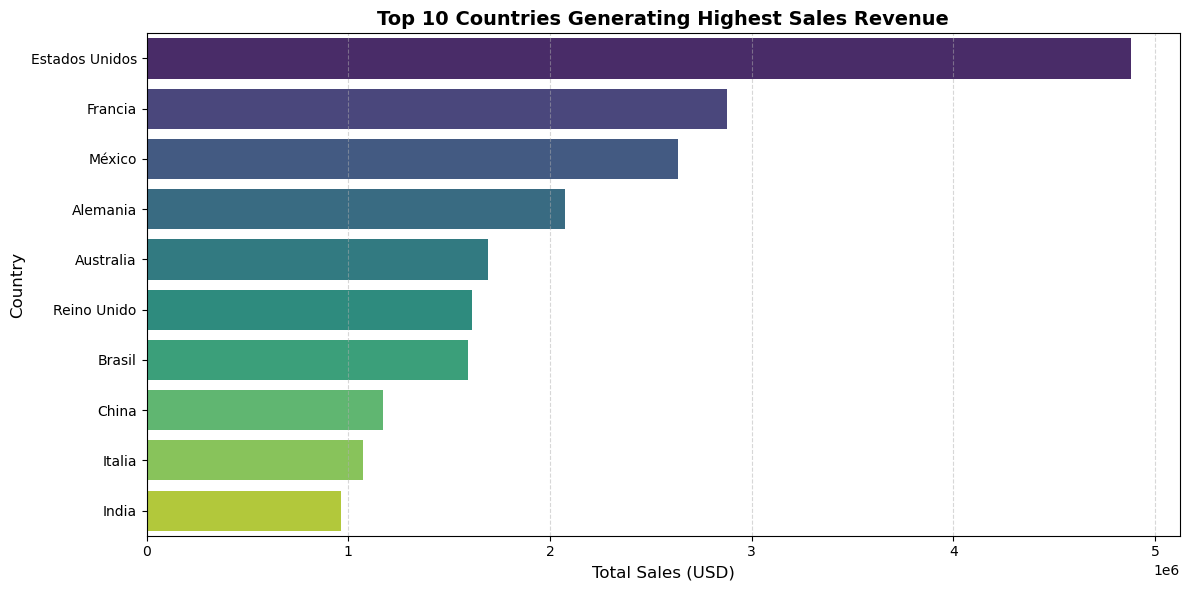

In [25]:
#Cell 15: Top 10 Countries by Total Sales
plt.figure(figsize=(12, 6))

# Group by country and calculate total sales
top_countries = df_clean.groupby('Order Country')['Sales'].sum().nlargest(10)

# Plot Horizontal Bar Chart
sns.barplot(
    x=top_countries.values, 
    y=top_countries.index, 
    palette='viridis'
)

plt.title('Top 10 Countries Generating Highest Sales Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales (USD)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\EELU\AppData\Local\Temp\ipykernel_11068\44957613.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Late_delivery_risk', palette='flare')


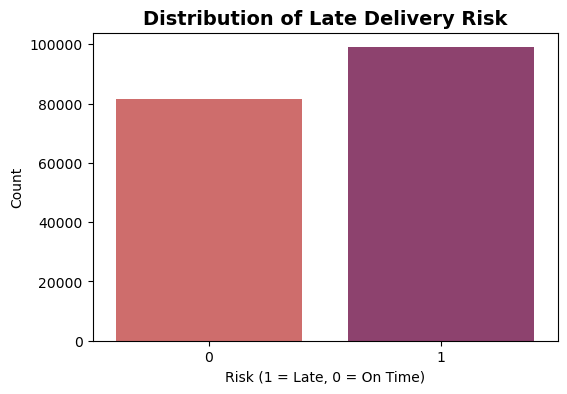

In [26]:
#  Distribution of Late Delivery Risk
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Late_delivery_risk', palette='flare')
plt.title('Distribution of Late Delivery Risk', fontsize=14, fontweight='bold')
plt.xlabel('Risk (1 = Late, 0 = On Time)')
plt.ylabel('Count')
plt.show()

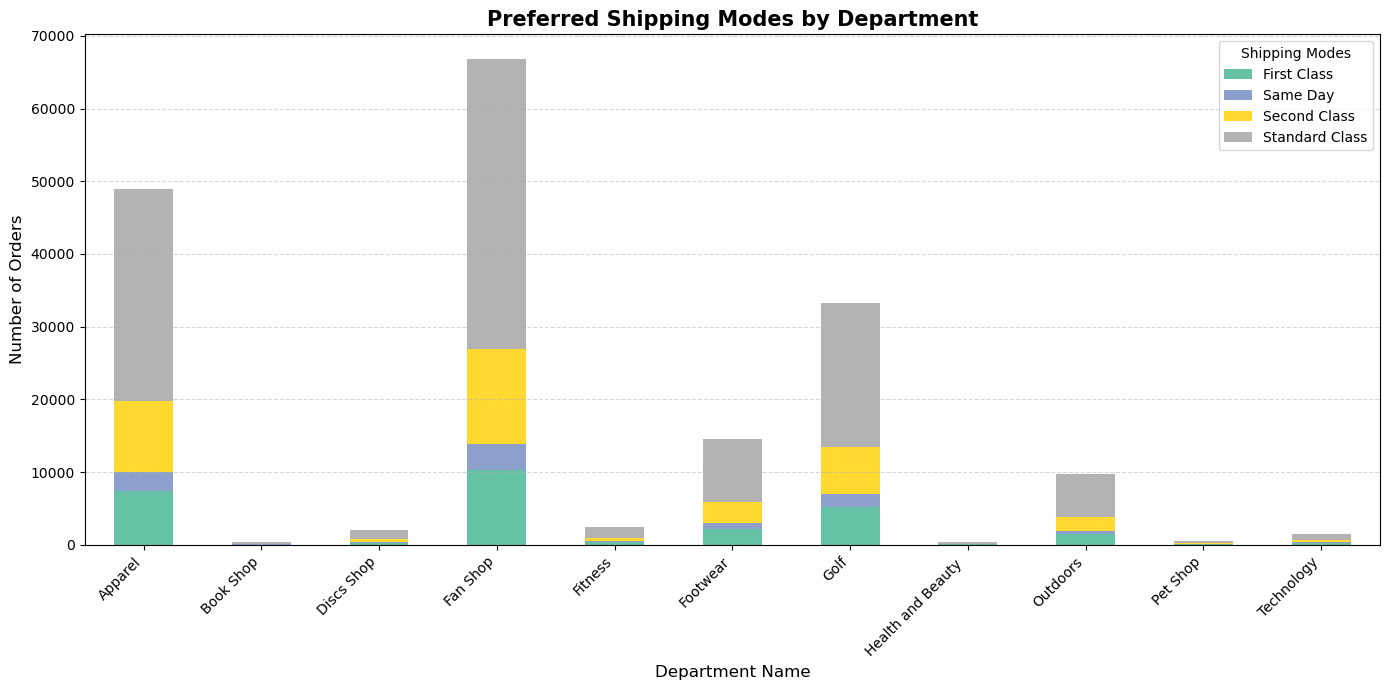

In [27]:
#  Shipping Modes Utilized across Departments
plt.figure(figsize=(14, 7))

# Create a cross-tabulation of Department and Shipping Mode
shipping_dept = pd.crosstab(df_clean['Department Name'], df_clean['Shipping Mode'])

# Plot Stacked Bar Chart
shipping_dept.plot(kind='bar', stacked=True, figsize=(14, 7), ax=plt.gca(), cmap='Set2')

plt.title('Preferred Shipping Modes by Department', fontsize=15, fontweight='bold')
plt.xlabel('Department Name', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Shipping Modes')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

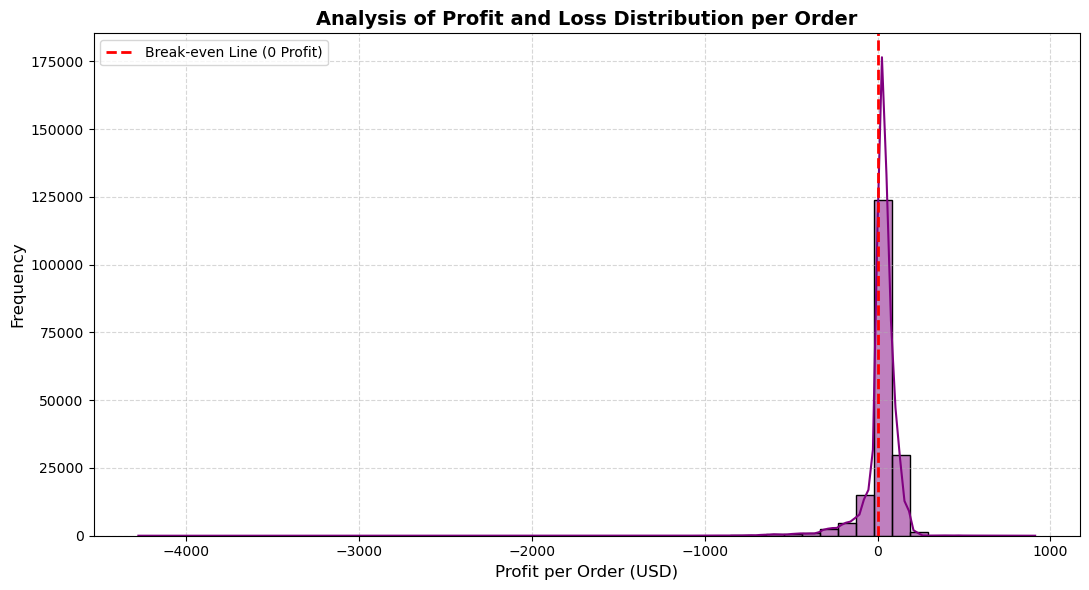

In [28]:
#  Distribution of Profit per Order
plt.figure(figsize=(11, 6))

# Plot Histogram with Kernel Density Estimate
sns.histplot(
    data=df_clean, 
    x='Order Profit Per Order', 
    bins=50, 
    kde=True, 
    color='purple'
)

# Add a red vertical line at 0 profit to clearly see losses
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Break-even Line (0 Profit)')

plt.title('Analysis of Profit and Loss Distribution per Order', fontsize=14, fontweight='bold')
plt.xlabel('Profit per Order (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\EELU\AppData\Local\Temp\ipykernel_11068\3626500568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Delivery Status', order=df['Delivery Status'].value_counts().index, palette='crest')


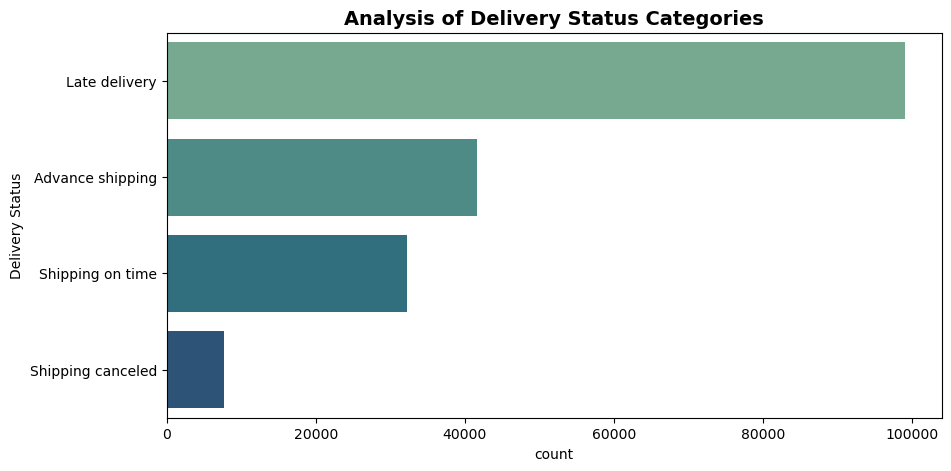

In [29]:
# . Delivery Status Count
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Delivery Status', order=df['Delivery Status'].value_counts().index, palette='crest')
plt.title('Analysis of Delivery Status Categories', fontsize=14, fontweight='bold')
plt.show()

# Feature Selection using Extra Trees Classifier (ML)

Top 8 Features selected are:
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Shipping Mode', 'Type', 'Customer Street', 'Order Customer Id', 'Customer Id', 'Order Item Id']


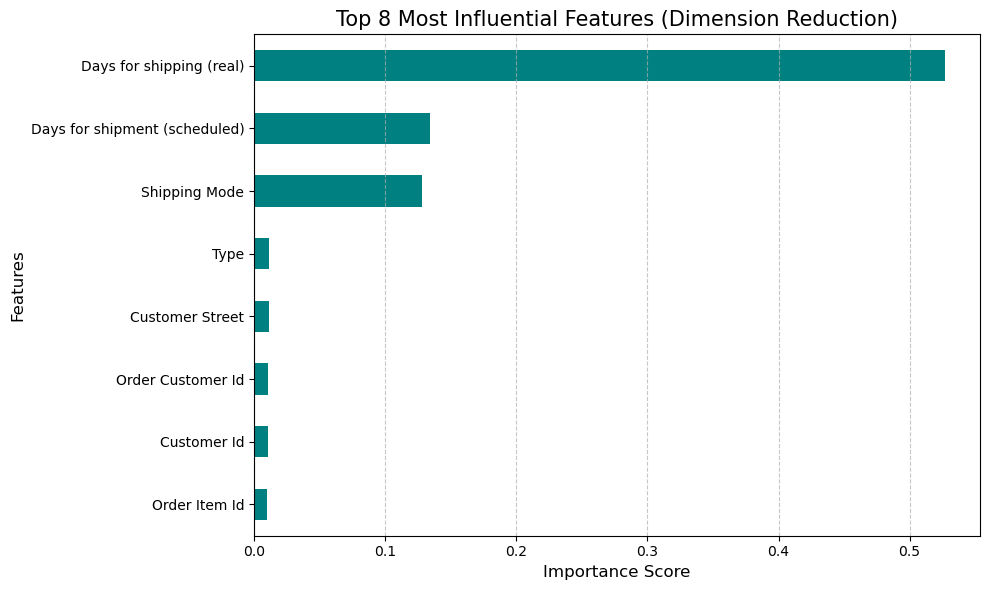

In [30]:
#  Feature Selection using Extra Trees Classifier
from sklearn.ensemble import ExtraTreesClassifier

# 1. Initialize and train the Extra Trees model
model_for_selection = ExtraTreesClassifier(random_state=42)
model_for_selection.fit(X_train, y_train)

# 2. Calculate and extract feature importances
feat_importances = pd.Series(model_for_selection.feature_importances_, index=X_train.columns)
top_8_features = feat_importances.nlargest(8).index.tolist()

# 3. Print the selected features
print("Top 8 Features selected are:")
print(top_8_features)

# 4. Plot the top 8 feature importances
plt.figure(figsize=(10, 6))
feat_importances.nlargest(8).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Top 8 Most Influential Features (Dimension Reduction)', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [31]:
# Cell 10: Filter Train and Test datasets using top 8 features

X_train_selected = X_train[top_8_features]
X_test_selected = X_test[top_8_features]

print("=== Datasets Filtered Successfully ===")
print(f"New X_train Shape: {X_train_selected.shape}")
print(f"New X_test Shape: {X_test_selected.shape}")

=== Datasets Filtered Successfully ===
New X_train Shape: (144415, 8)
New X_test Shape: (36104, 8)


In [32]:
# Cell 11: Initialize and Train the Random Forest Model
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
final_model = RandomForestClassifier(random_state=42, n_estimators=100)

# Train the model
final_model.fit(X_train_selected, y_train)

# Make predictions on the testing set
y_pred = final_model.predict(X_test_selected)

print("✅ Final Model training completed successfully!")

✅ Final Model training completed successfully!


# Confusion Matrix

=== Model Accuracy: 0.9956 ===

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     16307
           1       0.99      1.00      1.00     19797

    accuracy                           1.00     36104
   macro avg       1.00      1.00      1.00     36104
weighted avg       1.00      1.00      1.00     36104



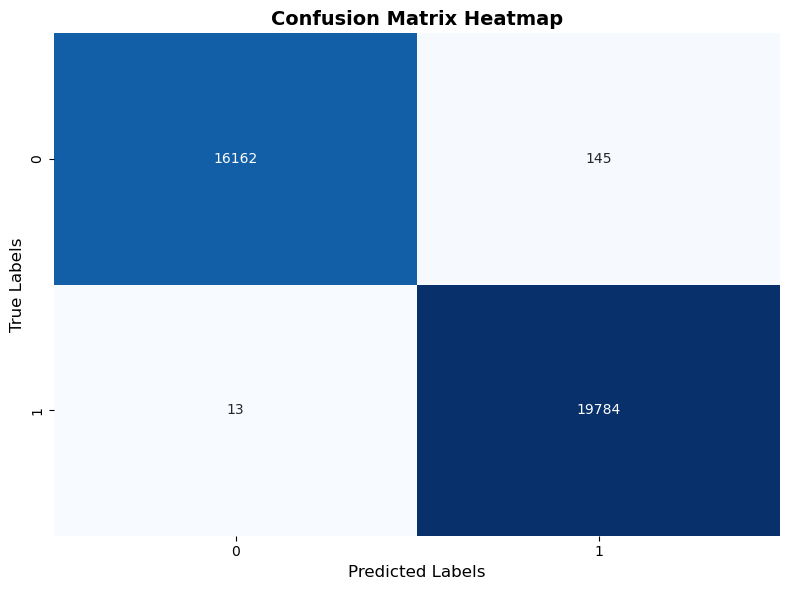

In [33]:
#  Performance Evaluation and Confusion Matrix Heatmap
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Print Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"=== Model Accuracy: {accuracy:.4f} ===\n")

# 2. Print Detailed Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()

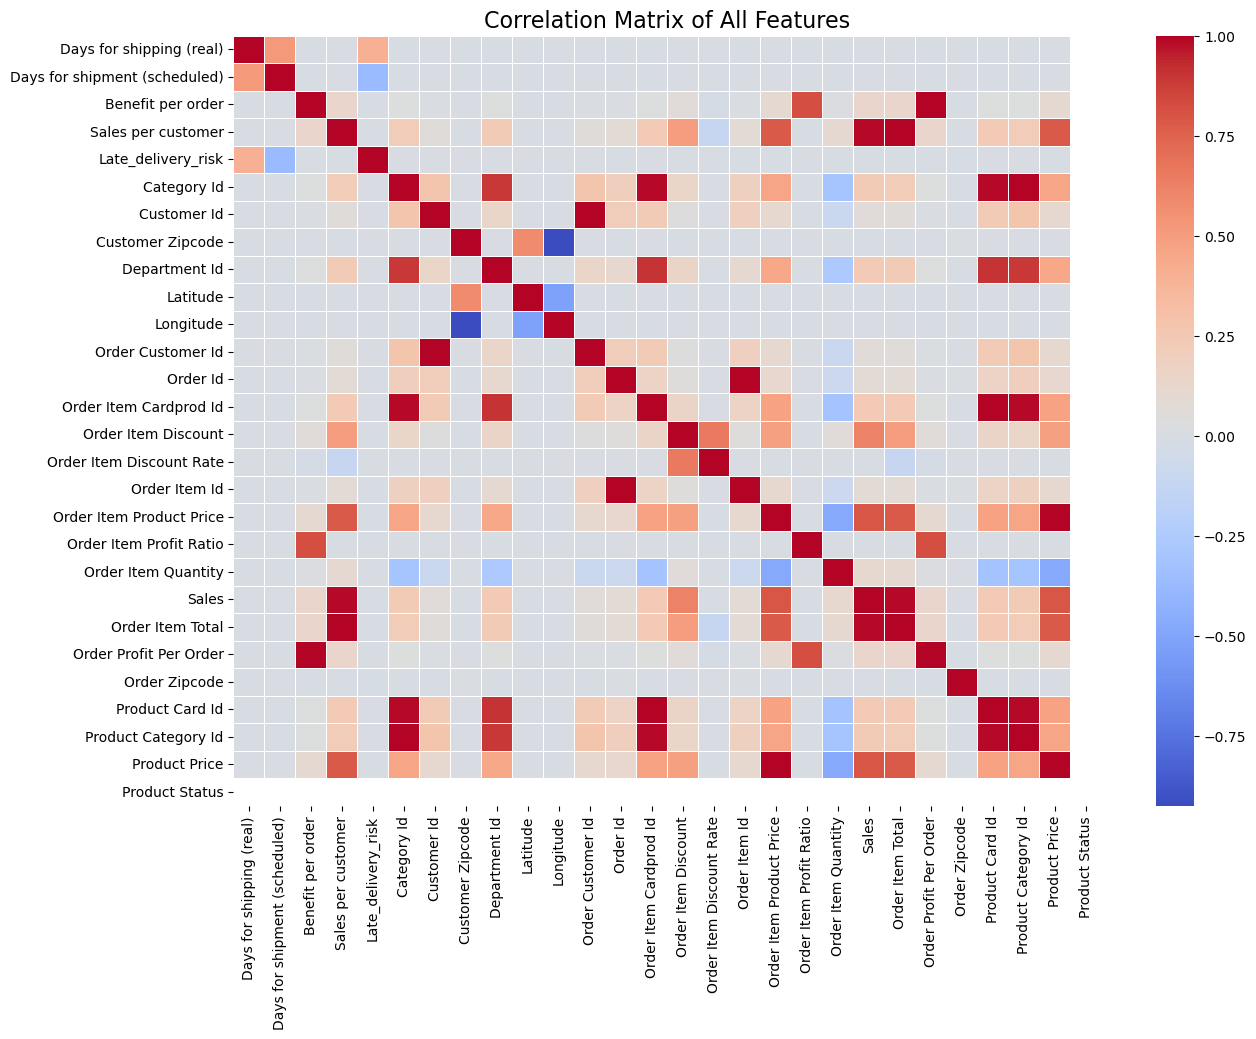

In [34]:
plt.figure(figsize=(14, 10))

# Fixed line: added numeric_only=True
corr_matrix = df.corr(numeric_only=True) 

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of All Features', fontsize=16)
plt.show()

# Save the Trained Model

In [35]:
#  Save the Trained Model and Cleaned Dataset for Deployment
import joblib

# 1. Save the final trained Random Forest model
joblib.dump(final_model, 'dataco_final_rf_model.pkl')

# 2. Save the top features list to remember what columns the model needs
joblib.dump(top_8_features, 'model_features.pkl')

# 3. Export the cleaned dataframe to a new CSV file
df_clean.to_csv('DataCoSupplyChainDataset_Cleaned.csv', index=False)

print("=== Project Successfully Saved! ===")
print("1. Trained Model saved as: 'dataco_final_rf_model.pkl'")
print("2. Features List saved as: 'model_features.pkl'")
print("3. Cleaned Dataset saved as: 'DataCoSupplyChainDataset_Cleaned.csv'")

=== Project Successfully Saved! ===
1. Trained Model saved as: 'dataco_final_rf_model.pkl'
2. Features List saved as: 'model_features.pkl'
3. Cleaned Dataset saved as: 'DataCoSupplyChainDataset_Cleaned.csv'


# Accuracy

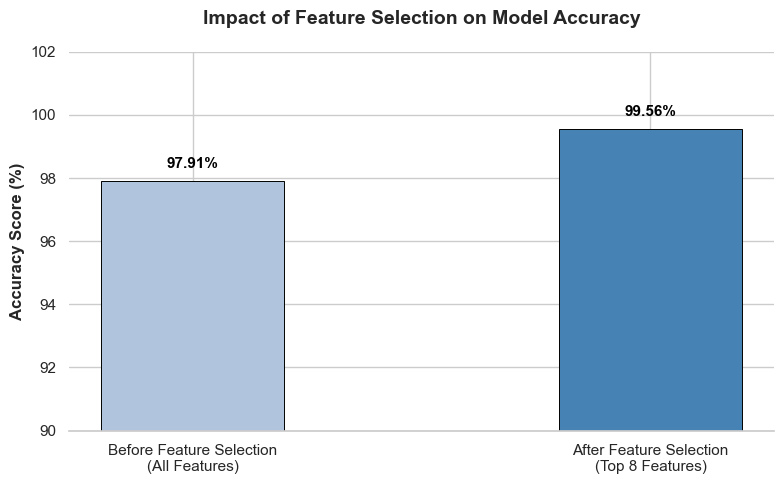

In [36]:

# 1. Prepare the data based on your model's exact results
stages = ['Before Feature Selection\n(All Features)', 'After Feature Selection\n(Top 8 Features)']
accuracy_scores = [97.91, 99.56] 

# 2. Set up the figure size and theme
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid") 

# 3. Plot the bars with professional colors
colors = ['#b0c4de', '#4682b4'] 
bars = plt.bar(stages, accuracy_scores, color=colors, width=0.4, edgecolor='black', linewidth=0.7)

# 4. Add titles and labels with clear fonts
plt.title('Impact of Feature Selection on Model Accuracy', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Accuracy Score (%)', fontsize=12, fontweight='bold')
plt.ylim(90, 102) 

# 5. Automatically add the percentage text above each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, f'{yval}%', 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

# 6. Clean up the borders
sns.despine(left=True, bottom=False)

# 7. Layout adjustment and showing the plot
plt.tight_layout()
plt.show()